In [2]:
import pyguidos
import shutil
import rasterio
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
cwd = os.getcwd()

src_map = os.path.join(cwd, 'examples/data/3classesmap.tif')
cl3_map = os.path.join(cwd, 'examples/input/3classesmap.tif')
shutil.copy(src_map, cl3_map)


'/home/caudugi/git_rep/pyguidosx/examples/input/3classesmap.tif'

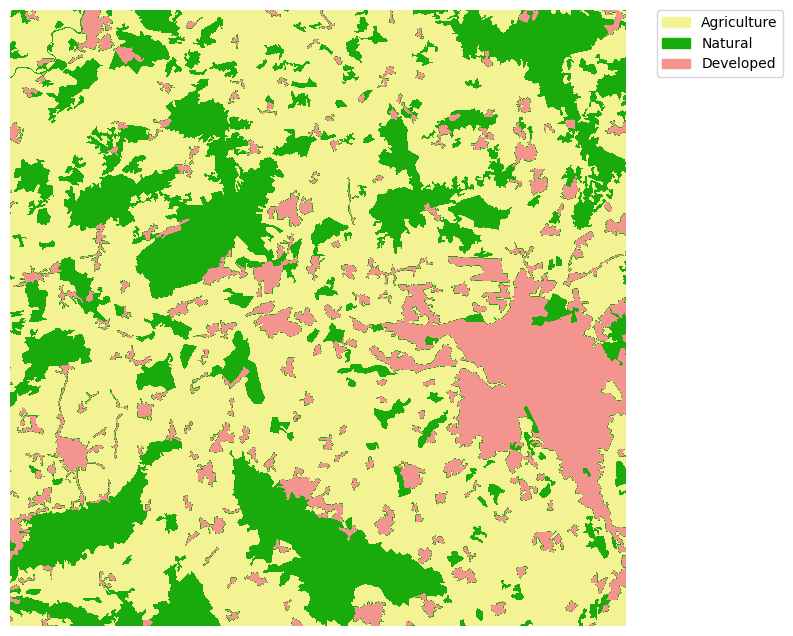

In [5]:
with rasterio.open(cl3_map) as src:
    data = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))

class_scheme = {
    1: ['Agriculture', '#f3f394'], 
    2: ['Natural', '#19aa0c'],     
    3: ['Developed', '#f4948e']      
}
colors = [class_[1] for class_ in class_scheme.values()]
cmap = ListedColormap(colors)

im = ax.imshow(data, cmap=cmap, vmin=0.5, vmax=3.5)

patches = []
for val in sorted(class_scheme.keys()): 
    label = class_scheme[val][0] 
    color = class_scheme[val][1] 
    patch = mpatches.Patch(color=color, label=label)
    patches.append(patch)
legend = ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.show()

In [7]:
in_dir = os.path.join(cwd, 'examples/input')
out_dir = os.path.join(cwd, 'examples/output')


pyguidos.gwb_lm(in_dir, out_dir, kdim=23)

GWB_LM using:
dir_input= /home/caudugi/git_rep/pyguidosx/examples/input
dir_output= /home/caudugi/git_rep/pyguidosx/examples/output
Done with: 3classesmap.tif
LM finished sucessfully



In [11]:
map_name = cl3_map.split('/')[-1][:-4]
res_dir = os.path.join(cwd, 'examples/output', map_name + '_lm')

lm_map = os.path.join(res_dir, map_name + '_lm_23.tif')
lm_map103 = os.path.join(res_dir, map_name + '_lm_23_103class.tif')
lm_map_png = os.path.join(res_dir, map_name + '_lm_23_heatmap.png')
lm_map_csv = os.path.join(res_dir, map_name + '_lm_23_heatmap.csv')

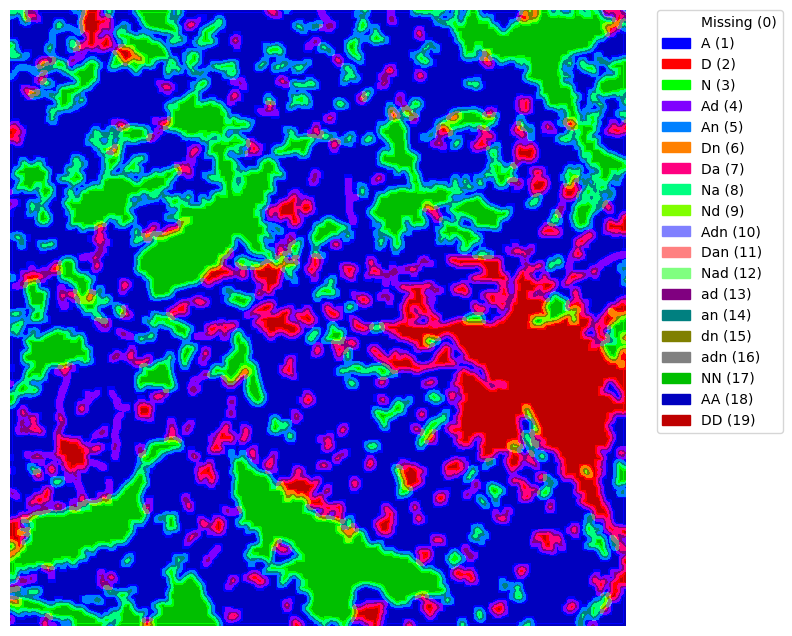

In [15]:
with rasterio.open(lm_map) as src:
    data = src.read(1)

class_scheme = [
    {'name': 'Missing', 'values': [0], 'color': '#FFFFFF', 'label': 'Missing (0)'},
    {'name': 'A', 'values': [1], 'color': '#0000FF', 'label': 'A (1)'},  
    {'name': 'D', 'values': [2], 'color': '#FF0000', 'label': 'D (2)'}, 
    {'name': 'N', 'values': [3], 'color': '#00FF00', 'label': 'N (3)'},  
    {'name': 'Ad', 'values': [4], 'color': '#8000FF', 'label': 'Ad (4)'}, 
    {'name': 'An', 'values': [5], 'color': '#0080FF', 'label': 'An (5)'}, 
    {'name': 'Dn', 'values': [6], 'color': '#FF8000', 'label': 'Dn (6)'}, 
    {'name': 'Da', 'values': [7], 'color': '#FF0080', 'label': 'Da (7)'}, 
    {'name': 'Na', 'values': [8], 'color': '#00FF80', 'label': 'Na (8)'}, 
    {'name': 'Nd', 'values': [9], 'color': '#80FF00', 'label': 'Nd (9)'}, 
    {'name': 'Adn', 'values': [10], 'color': '#8080FF', 'label': 'Adn (10)'},
    {'name': 'Dan', 'values': [11], 'color': '#FF8080', 'label': 'Dan (11)'}, 
    {'name': 'Nad', 'values': [12], 'color': '#80FF80', 'label': 'Nad (12)'}, 
    {'name': 'ad', 'values': [13], 'color': '#800080', 'label': 'ad (13)'},
    {'name': 'an', 'values': [14], 'color': '#008080', 'label': 'an (14)'}, 
    {'name': 'dn', 'values': [15], 'color': '#808000', 'label': 'dn (15)'}, 
    {'name': 'adn', 'values': [16], 'color': '#808080', 'label': 'adn (16)'},  
    {'name': 'NN', 'values': [17], 'color': '#00BF00', 'label': 'NN (17)'},  
    {'name': 'AA', 'values': [18], 'color': '#0000BF', 'label': 'AA (18)'},  
    {'name': 'DD', 'values': [19], 'color': '#BF0000', 'label': 'DD (19)'}   
]

byte_values = sorted(list(set(val for entry in class_scheme for val in entry['values'])))
value_to_color_map_for_scheme = {}
for category in class_scheme:
    for val in category['values']:
        value_to_color_map_for_scheme[val] = category['color']

norm_boundaries = []
cmap_colors = []
norm_boundaries.append(byte_values[0] - 0.5)
for val in byte_values:
    cmap_colors.append(value_to_color_map_for_scheme.get(val, '#808080'))
    norm_boundaries.append(val + 0.5)
cmap = ListedColormap(cmap_colors)
norm = BoundaryNorm(norm_boundaries, cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')


categories_for_legend = set()
for val in byte_values:
    found_category = False
    for category in class_scheme:
        if val in category['values']:
            categories_for_legend.add(category['name'])
            found_category = True
            break

patches = []
for category in class_scheme:
    if category['name'] in categories_for_legend:
        patch = mpatches.Patch(color=category['color'], label=category['label'])
        patches.append(patch)

legend = ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.show()

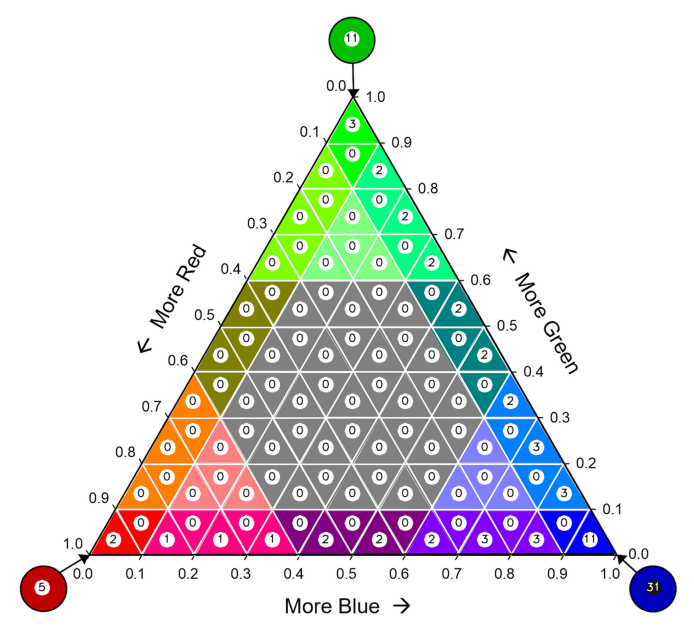

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
img = mpimg.imread(lm_map_png)
ax.imshow(img)
ax.axis('off')
plt.show()